Using latest, cutting edge techniques to understand how current neural networks work, which will help us create improvements and move the AI field forward.

> Understanding current ideas > trying to come up with new ideas, Ilya Sutskever

Importing libraries/ dependencies..

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

Defining class definition for NN:

In [2]:
class InterpretableNeuralNet:
    def __init__(self, input_size, hidden_size, output_size):
        # initialization based on specified arguments
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Initialize weights with no biases
        # Each weight represent each layer
        # First layer constructing input nuerons with hidden neurons 
        #   with random number multiply by 0.5
        self.w1 = np.random.randn(input_size, hidden_size) * 0.5
        # Second layer constructing the continuation from first layer
        #   constructing hidden neurons to output neurons
        #   with random number multiply by 0.5
        self.w2 = np.random.randn(hidden_size, output_size) * 0.5   

        # Store training history for analysis
        self.loss_history = []
        self.weight_history = {'w1': [], 'w2': []}

    def sigmoid(self, x):
        # Clip to prevent overflow
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, x):
        # Calculation for first layer
        # Remember: in this NN, there is no bias
        # Calculate the weighted sum (x * w1 = z1)
        self.z1 = np.dot(x, self.w1)
        # Calculate the softmax() (a1) through activation function (sigmoid)
        # Calculate the activated nuerons (softmax(z1) = a1)
        self.a1 = self.sigmoid(self.z1)

        # Calculation for second layer
        # The input value for second layer is a1
        # Calculate the weighted sum (a1(input) * w1 = z2)
        self.z2 = np.dot(self.a1, self.w2)
        # Calculate the softmax() (a2) through activation function (sigmoid)
        # Calculate the activated nuerons (softmax(z2) = a2)
        self.a2 = self.sigmoid(self.z2)

        # The activated function nueron a2 becomes as output from x
        #   x  -> first layer (x.w1 = z1 -> softmax(z1) = a1)
        #   a1 -> second layer (a1.w1 = z2 -> softmax(z2) = z2)
        return self.a2

    def train(self, x, y, epochs=1000, learning_rate=1.0):
        for i in range(epochs):
            # make forward feed inside of NN model
            # Remember: forward feed process/trace
            #   First layer: x (input) -> x.w1 -> z1 -> softmax(z1) -> a1
            #   Second layer: a1 -> a1.w2 -> z2 -> softmax(z2) -> a2 (output)
            output = self.forward(x)

            # Calculate the loss
            #   differences between y(ground truth) and output(predicted)
            #   differences needed for correction
            # OR error = output - y
            error = y - output

            # Backpropagation
            # Reverse track from output for second layer
            # Calculate the delta_output (da2/dw2) (rate of change for correction output - a2(prediction(inside second layer))) 
            # before activation function 
            #   sigmoid_derivative is used to get rate of change in specific output
            delta_output = error * self.sigmoid_derivative(output)
            # Calculate the gradient_w2 (rate of change for w2 correction)
            #   by dot product self.a1.T(input of 2nd layer) * delta_output (rate of change for correction output - a2)
            grad_w2 = np.dot(self.a1.T, delta_output)

            # Reverse track from output(a1) for first layer
            # Calculate the delta_hidden (da1/dw1) (rate of change for correction output - a1(inside first layer)) 
            # before activation function
            #   sigmoid_derivative is used to get rate of change in specific a1
            delta_hidden = np.dot(delta_output, self.w2.T) * self.sigmoid_derivative(self.a1)
            # Calculate the gradient_w1 (rate of change for w1 correction)
            #   by dot product x.T(input of 1st layer) * delta_hidden (rate of change for correction - a1)
            grad_w1 = np.dot(x.T, delta_hidden)

            # Assigning new weights based on gradient descent multiply with learning rate
            # OR self.wn = self.wn - learning_rate * grad_wn
            self.w2 += learning_rate * grad_w2
            self.w1 += learning_rate * grad_w1

            # Store history for interpretability (MSE - Mean Square Error)
            loss = np.mean(np.square(error))
            self.loss_history.append(loss)

            if i % 50 == 0:  
                # Store weights less frequently to save memory
                self.weight_history['w1'].append(self.w1.copy())
                self.weight_history['w2'].append(self.w2.copy())

            if i % 100 == 0:
                print(f"Epoch {i}, Loss: {loss:.6f}")

    # === INTERPRETABILITY METHODS ===

    def visualize_network_architecture(self):
        """Visualize the network structure with current weights"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))

        # Node positions
        input_pos = [(0, i) for i in range(self.input_size)]
        hidden_pos = [(2, i - self.hidden_size/2 + 0.5) for i in range(self.hidden_size)]
        output_pos = [(4, 0)]

        # Draw connections with weight-based thickness and color
        for i, (x1, y1) in enumerate(input_pos):
            for j, (x2, y2) in enumerate(hidden_pos):
                weight = self.w1[i, j]
                color = 'red' if weight < 0 else 'blue'
                alpha = min(abs(weight) / np.max(np.abs(self.w1)), 1.0)
                linewidth = max(abs(weight) * 3, 0.5)
                ax.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=linewidth)

                # Add weight labels
                mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mid_x, mid_y, f'{weight:.2f}', fontsize=8, ha='center',
                       bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.7))

        for i, (x1, y1) in enumerate(hidden_pos):
            for j, (x2, y2) in enumerate(output_pos):
                weight = self.w2[i, j]
                color = 'red' if weight < 0 else 'blue'
                alpha = min(abs(weight) / np.max(np.abs(self.w2)), 1.0)
                linewidth = max(abs(weight) * 3, 0.5)
                ax.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=linewidth)

                # Add weight labels
                mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mid_x, mid_y, f'{weight:.2f}', fontsize=8, ha='center',
                       bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.7))

        # Draw nodes
        for i, (x, y) in enumerate(input_pos):
            circle = plt.Circle((x, y), 0.2, color='lightgreen', zorder=3)
            ax.add_patch(circle)
            ax.text(x, y, f'I{i}', ha='center', va='center', fontweight='bold')

        for i, (x, y) in enumerate(hidden_pos):
            circle = plt.Circle((x, y), 0.2, color='lightblue', zorder=3)
            ax.add_patch(circle)
            ax.text(x, y, f'H{i}', ha='center', va='center', fontweight='bold')

        for i, (x, y) in enumerate(output_pos):
            circle = plt.Circle((x, y), 0.2, color='lightcoral', zorder=3)
            ax.add_patch(circle)
            ax.text(x, y, f'O{i}', ha='center', va='center', fontweight='bold')

        # Add layer labels
        ax.text(0, -1.5, 'Input Layer', ha='center', fontsize=12, fontweight='bold')
        ax.text(2, -1.5, 'Hidden Layer', ha='center', fontsize=12, fontweight='bold')
        ax.text(4, -1.5, 'Output Layer', ha='center', fontsize=12, fontweight='bold')

        ax.set_xlim(-0.5, 4.5)
        ax.set_ylim(-2, max(self.input_size, self.hidden_size) + 0.5)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('Neural Network Architecture\n(Line thickness = |weight|, Blue = positive, Red = negative)',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def analyze_hidden_neurons(self, x, y):
        """Analyze what each hidden neuron learns"""
        self.forward(x)

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Hidden neuron activations for each input
        ax1 = axes[0, 0]
        activations = self.a1
        im1 = ax1.imshow(activations.T, cmap='RdYlBu', aspect='auto')
        ax1.set_title('Hidden Neuron Activations')
        ax1.set_xlabel('Input Samples')
        ax1.set_ylabel('Hidden Neurons')
        ax1.set_xticks(range(len(x)))
        ax1.set_xticklabels([f'{inp}' for inp in x])
        plt.colorbar(im1, ax=ax1)

        # Plot 2: Input weights to each hidden neuron
        ax2 = axes[0, 1]
        im2 = ax2.imshow(self.w1.T, cmap='RdBu', aspect='auto')
        ax2.set_title('Input → Hidden Weights')
        ax2.set_xlabel('Input Features')
        ax2.set_ylabel('Hidden Neurons')
        ax2.set_xticks(range(self.input_size))
        ax2.set_xticklabels([f'Input {i}' for i in range(self.input_size)])
        plt.colorbar(im2, ax=ax2)

        # Plot 3: Hidden to output weights
        ax3 = axes[1, 0]
        bars = ax3.bar(range(self.hidden_size), self.w2.flatten(),
                      color=['red' if w < 0 else 'blue' for w in self.w2.flatten()])
        ax3.set_title('Hidden → Output Weights')
        ax3.set_xlabel('Hidden Neurons')
        ax3.set_ylabel('Weight Value')
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01*np.sign(height),
                    f'{height:.2f}', ha='center', va='bottom' if height > 0 else 'top')

        # Plot 4: Neuron specialization analysis
        ax4 = axes[1, 1]
        # Calculate how much each neuron contributes to correct classifications
        contributions = []
        for i in range(self.hidden_size):
            # Contribution = activation * weight_to_output
            contrib = self.a1[:, i] * self.w2[i, 0]
            contributions.append(contrib)

        contributions = np.array(contributions).T
        im4 = ax4.imshow(contributions.T, cmap='RdYlGn', aspect='auto')
        ax4.set_title('Neuron Contributions to Output')
        ax4.set_xlabel('Input Samples')
        ax4.set_ylabel('Hidden Neurons')
        ax4.set_xticks(range(len(x)))
        ax4.set_xticklabels([f'{inp}' for inp in x])
        plt.colorbar(im4, ax=ax4)

        plt.tight_layout()
        plt.show()

        # Print neuron analysis
        print("\n=== HIDDEN NEURON ANALYSIS ===")
        for i in range(self.hidden_size):
            print(f"\nNeuron {i}:")
            print(f"  Weights from inputs: {self.w1[:, i]}")
            print(f"  Weight to output: {self.w2[i, 0]:.3f}")
            print(f"  Activations: {self.a1[:, i]}")

            # Interpret what this neuron might be detecting
            if abs(self.w1[0, i]) > abs(self.w1[1, i]):
                dominant_input = "Input 0" if self.w1[0, i] > 0 else "NOT Input 0"
            else:
                dominant_input = "Input 1" if self.w1[1, i] > 0 else "NOT Input 1"

            output_influence = "promotes" if self.w2[i, 0] > 0 else "inhibits"
            print(f"  Interpretation: Responds to {dominant_input}, {output_influence} output")

    def plot_decision_boundary(self, resolution=100):
        """Visualize the decision boundary learned by the network"""
        # Create a mesh of points
        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                            np.linspace(y_min, y_max, resolution))

        # Get predictions for all points
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        predictions = []
        for point in mesh_points:
            pred = self.forward(point.reshape(1, -1))
            predictions.append(pred[0, 0])

        predictions = np.array(predictions).reshape(xx.shape)

        # Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Decision boundary
        contour = ax1.contourf(xx, yy, predictions, levels=20, alpha=0.8, cmap='RdYlBu')
        ax1.contour(xx, yy, predictions, levels=[0.5], colors='black', linewidths=2)

        # Plot training points
        colors = ['red', 'blue']
        labels = ['Class 0', 'Class 1']
        x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        y_train = np.array([0, 1, 1, 0])

        for i in range(len(x_train)):
            ax1.scatter(x_train[i, 0], x_train[i, 1],
                       c=colors[y_train[i]], s=200, edgecolors='black', linewidth=2)
            ax1.annotate(f'({x_train[i, 0]},{x_train[i, 1]})\nTarget: {y_train[i]}',
                        (x_train[i, 0], x_train[i, 1]),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        ax1.set_xlim(x_min, x_max)
        ax1.set_ylim(y_min, y_max)
        ax1.set_xlabel('Input 0')
        ax1.set_ylabel('Input 1')
        ax1.set_title('Decision Boundary\n(Black line = 0.5 threshold)')
        ax1.grid(True, alpha=0.3)
        plt.colorbar(contour, ax=ax1, label='Output Probability')

        # 3D surface plot
        ax2 = fig.add_subplot(122, projection='3d')
        surf = ax2.plot_surface(xx, yy, predictions, cmap='RdYlBu', alpha=0.8)

        # Plot training points on surface
        for i in range(len(x_train)):
            pred = self.forward(x_train[i].reshape(1, -1))[0, 0]
            ax2.scatter(x_train[i, 0], x_train[i, 1], pred,
                       c=colors[y_train[i]], s=100, edgecolors='black')

        ax2.set_xlabel('Input 0')
        ax2.set_ylabel('Input 1')
        ax2.set_zlabel('Output')
        ax2.set_title('3D Output Surface')
        plt.colorbar(surf, ax=ax2, shrink=0.5)

        plt.tight_layout()
        plt.show()

    def analyze_training_dynamics(self):
        """Analyze how the network learned over time"""
        if not self.loss_history or not self.weight_history['w1']:
            print("No training history available. Train the network first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Loss curve
        ax1 = axes[0, 0]
        ax1.plot(self.loss_history)
        ax1.set_title('Training Loss Over Time')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Mean Squared Error')
        ax1.set_yscale('log')
        ax1.grid(True)

        # Weight evolution for w1
        ax2 = axes[0, 1]
        w1_history = np.array(self.weight_history['w1'])
        for i in range(self.input_size):
            for j in range(self.hidden_size):
                ax2.plot(w1_history[:, i, j], label=f'w1[{i},{j}]', alpha=0.7)
        ax2.set_title('Input→Hidden Weight Evolution')
        ax2.set_xlabel('Training Steps (×50 epochs)')
        ax2.set_ylabel('Weight Value')
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True)

        # Weight evolution for w2
        ax3 = axes[1, 0]
        w2_history = np.array(self.weight_history['w2'])
        for i in range(self.hidden_size):
            for j in range(self.output_size):
                ax3.plot(w2_history[:, i, j], label=f'w2[{i},{j}]', alpha=0.7)
        ax3.set_title('Hidden→Output Weight Evolution')
        ax3.set_xlabel('Training Steps (×50 epochs)')
        ax3.set_ylabel('Weight Value')
        ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax3.grid(True)

        # Weight magnitude distribution
        ax4 = axes[1, 1]
        final_w1_flat = self.w1.flatten()
        final_w2_flat = self.w2.flatten()

        ax4.hist(final_w1_flat, bins=15, alpha=0.6, label='Input→Hidden', color='blue')
        ax4.hist(final_w2_flat, bins=15, alpha=0.6, label='Hidden→Output', color='red')
        ax4.set_title('Final Weight Distribution')
        ax4.set_xlabel('Weight Value')
        ax4.set_ylabel('Frequency')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def feature_importance_analysis(self, x, y):
        """Analyze which input features are most important"""
        print("\n=== FEATURE IMPORTANCE ANALYSIS ===")

        # Method 1: Weight-based importance
        input_importance = np.abs(self.w1).sum(axis=1)
        print(f"Weight-based importance: {input_importance}")

        # Method 2: Gradient-based importance (simplified)
        self.forward(x)
        output_gradients = []

        for i in range(self.input_size):
            # Small perturbation
            x_perturbed = x.copy()
            x_perturbed[:, i] += 0.01

            original_output = self.forward(x)
            perturbed_output = self.forward(x_perturbed)

            gradient = np.mean(np.abs(perturbed_output - original_output))
            output_gradients.append(gradient)

        print(f"Gradient-based importance: {output_gradients}")

        # Visualize
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        x_pos = np.arange(self.input_size)

        # Normalize for comparison
        weight_imp_norm = input_importance / np.max(input_importance)
        grad_imp_norm = output_gradients / np.max(output_gradients)

        width = 0.35
        ax.bar(x_pos - width/2, weight_imp_norm, width, label='Weight-based', alpha=0.8)
        ax.bar(x_pos + width/2, grad_imp_norm, width, label='Gradient-based', alpha=0.8)

        ax.set_xlabel('Input Features')
        ax.set_ylabel('Normalized Importance')
        ax.set_title('Feature Importance Analysis')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'Input {i}' for i in range(self.input_size)])
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def xor_logic_analysis(self):
        """Specific analysis for XOR problem understanding"""
        print("\n=== XOR LOGIC ANALYSIS ===")
        print("XOR Truth Table:")
        print("Input 0 | Input 1 | Output")
        print("   0    |    0    |   0")
        print("   1    |    0    |   1")
        print("   0    |    1    |   1")
        print("   1    |    1    |   0")
        print()

        # Analyze what the network learned
        x_test = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        self.forward(x_test)

        print("Network's learned representation:")
        for i, (inp, hidden, output) in enumerate(zip(x_test, self.a1, self.a2)):
            print(f"Input {inp} -> Hidden {hidden} -> Output {output[0]:.4f}")

        # Check if network learned linearly separable representation
        print(f"\nHidden layer creates linearly separable representation:")
        print("For XOR to work, hidden layer should separate the data into linearly separable classes")

        # Plot hidden space
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Original input space (not linearly separable)
        colors = ['red', 'blue', 'blue', 'red']  # XOR labels
        ax1.scatter(x_test[:, 0], x_test[:, 1], c=colors, s=200, alpha=0.8)
        for i, (x, y) in enumerate(x_test):
            ax1.annotate(f'XOR={[0,1,1,0][i]}', (x, y), xytext=(5, 5),
                        textcoords='offset points')
        ax1.set_xlabel('Input 0')
        ax1.set_ylabel('Input 1')
        ax1.set_title('Original Input Space\n(Not Linearly Separable)')
        ax1.grid(True, alpha=0.3)

        # Hidden space (should be linearly separable)
        if self.hidden_size >= 2:
            ax2.scatter(self.a1[:, 0], self.a1[:, 1], c=colors, s=200, alpha=0.8)
            for i, (h1, h2) in enumerate(self.a1[:, :2]):
                ax2.annotate(f'XOR={[0,1,1,0][i]}', (h1, h2), xytext=(5, 5),
                            textcoords='offset points')
            ax2.set_xlabel('Hidden Neuron 0')
            ax2.set_ylabel('Hidden Neuron 1')
            ax2.set_title('Hidden Space\n(Should be Linearly Separable)')
        else:
            # If less than 2 hidden neurons, plot first hidden neuron vs a dummy dimension
            ax2.scatter(self.a1[:, 0], [0]*len(self.a1), c=colors, s=200, alpha=0.8)
            ax2.set_xlabel('Hidden Neuron 0')
            ax2.set_ylabel('Dummy Dimension')
            ax2.set_title('Hidden Space (1D projection)')

        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

Executing the NN..

Search for `nn = InterpretableNeuralNet(input_size=2, hidden_size=3, output_size=1)` with Ctrl+F to adjust it

Training Neural Network on XOR Problem...
Epoch 0, Loss: 0.257212
Epoch 100, Loss: 0.249925
Epoch 200, Loss: 0.247998
Epoch 300, Loss: 0.047067
Epoch 400, Loss: 0.014878
Epoch 500, Loss: 0.008359
Epoch 600, Loss: 0.005723
Epoch 700, Loss: 0.004322
Epoch 800, Loss: 0.003459
Epoch 900, Loss: 0.002877

=== FINAL PREDICTIONS ===
Input: [0 0], Target: 0, Predicted: 0.0377
Input: [0 1], Target: 1, Predicted: 0.9502
Input: [1 0], Target: 1, Predicted: 0.9398
Input: [1 1], Target: 0, Predicted: 0.0480

INTERPRETABILITY ANALYSIS


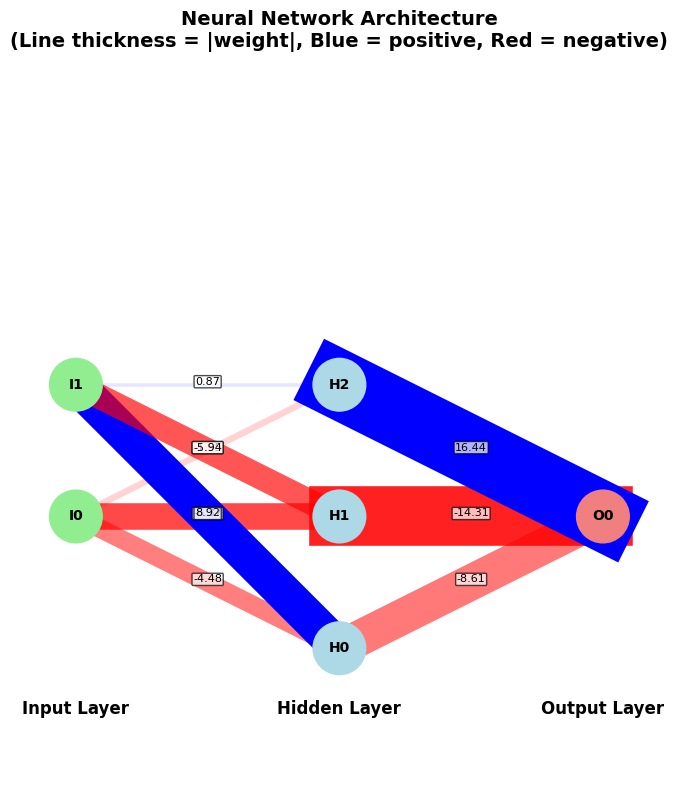

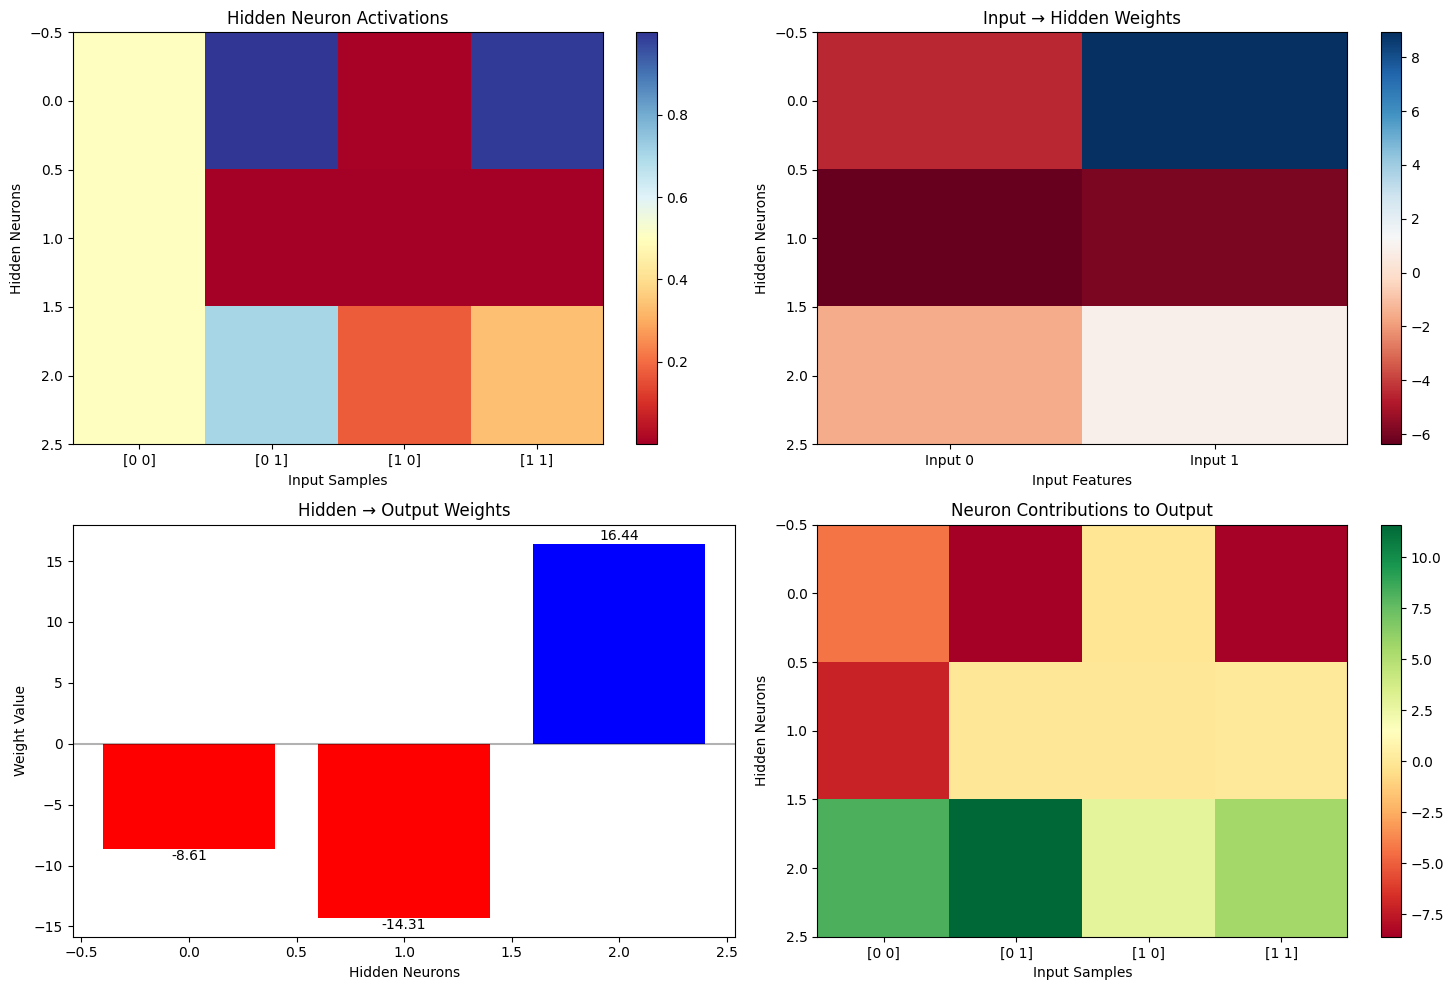


=== HIDDEN NEURON ANALYSIS ===

Neuron 0:
  Weights from inputs: [-4.47863886  8.92155081]
  Weight to output: -8.611
  Activations: [0.5        0.99986654 0.0112215  0.98837509]
  Interpretation: Responds to Input 1, inhibits output

Neuron 1:
  Weights from inputs: [-6.37245899 -5.94134417]
  Weight to output: -14.306
  Activations: [5.00000000e-01 2.62160326e-03 1.70504209e-03 4.48932749e-06]
  Interpretation: Responds to NOT Input 0, inhibits output

Neuron 2:
  Weights from inputs: [-1.55373904  0.87286755]
  Weight to output: 16.439
  Activations: [0.5        0.70534203 0.17454689 0.33606682]
  Interpretation: Responds to NOT Input 0, promotes output


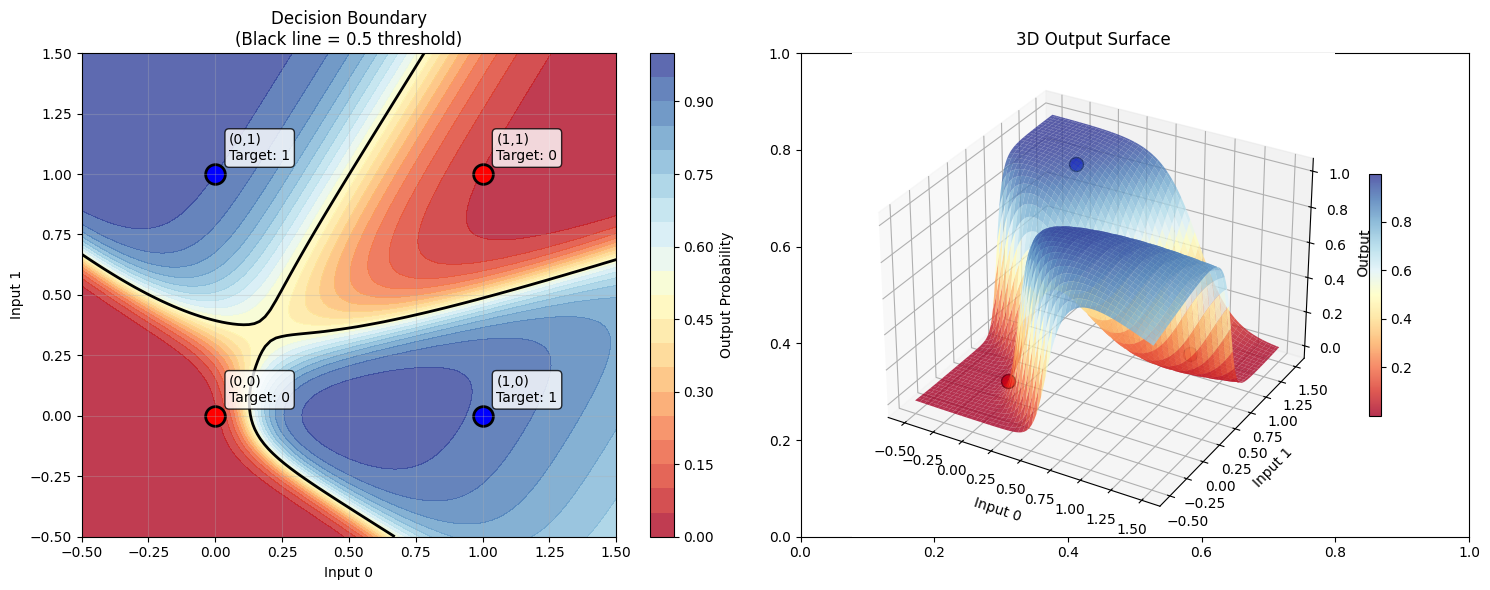

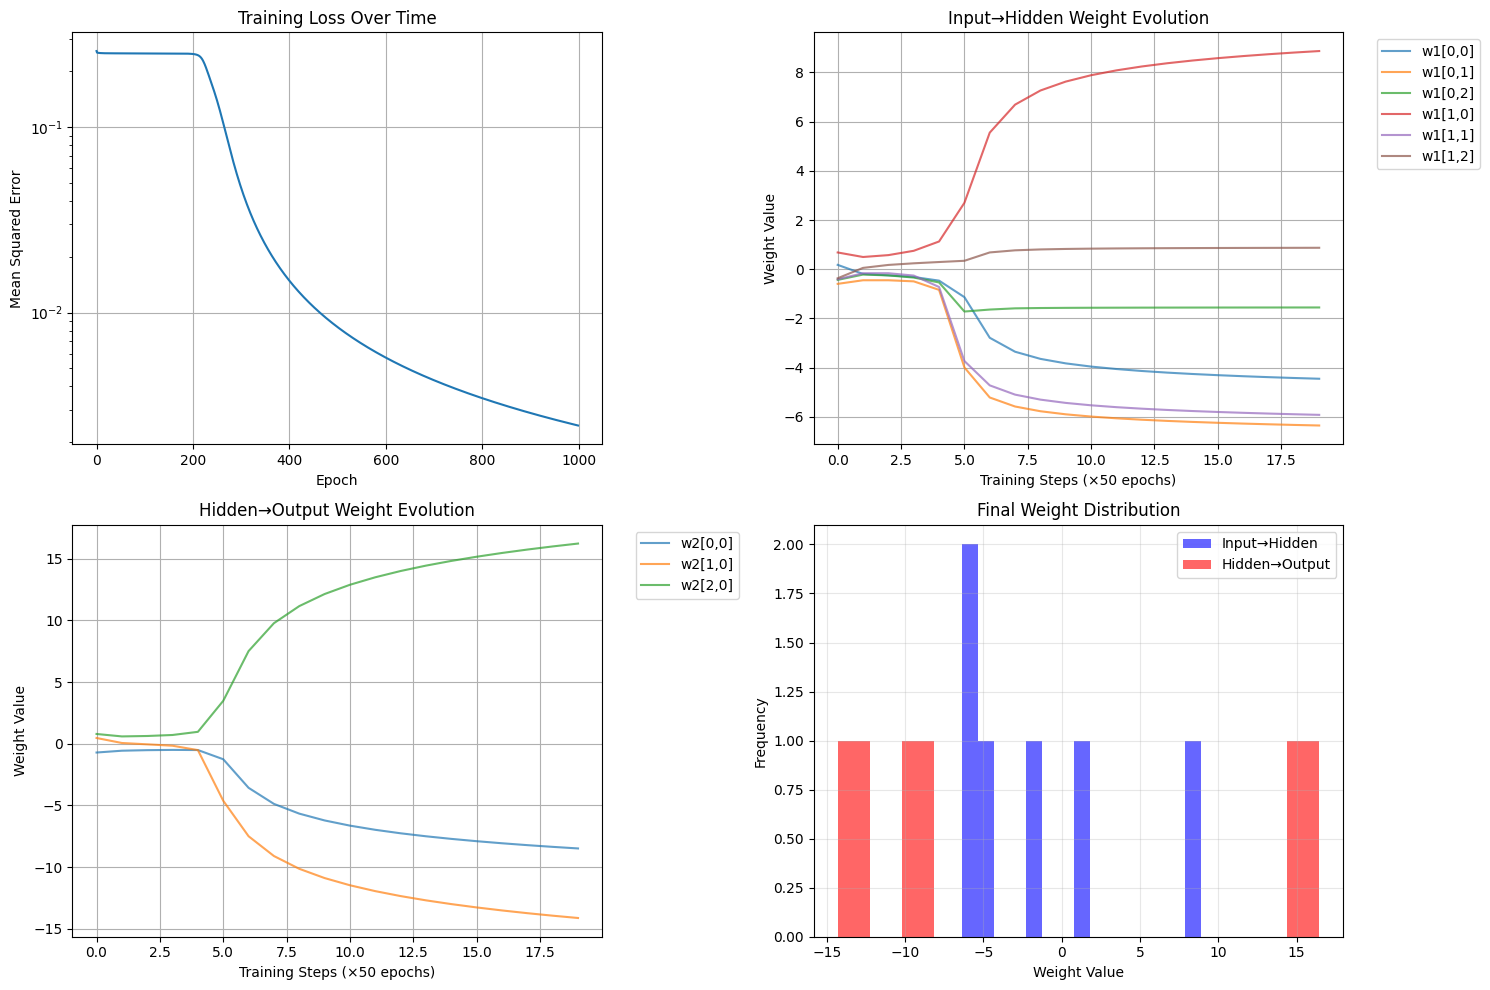


=== FEATURE IMPORTANCE ANALYSIS ===
Weight-based importance: [12.40483689 15.73576254]


UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

In [3]:
# Main execution
if __name__ == "__main__":
    # XOR dataset
    x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    print("Training Neural Network on XOR Problem...")
    # defining the NN by setting 
    # input size (match with array size x - input)
    # hidden size (set to how many hidden layers needed, for example, in this case is 3)
    # output size (match with array size y - output)
    nn = InterpretableNeuralNet(input_size=2, hidden_size=3, output_size=1)
    # train the NN by setting hyperparameters
    # input = x
    # output = y 
    # epochs = number of repetition of training for each data
    # learning_rate = number of learning rate need for optimization in backward()
    nn.train(x, y, epochs=1000, learning_rate=5.0)

    print("\n=== FINAL PREDICTIONS ===")
    for i in range(len(x)):
        output = nn.forward(x[i:i+1])
        print(f"Input: {x[i]}, Target: {y[i][0]}, Predicted: {output[0][0]:.4f}")

    print("\n" + "="*50)
    print("INTERPRETABILITY ANALYSIS")
    print("="*50)

    # Run all interpretability analyses
    nn.visualize_network_architecture()
    nn.analyze_hidden_neurons(x, y)
    nn.plot_decision_boundary()
    nn.analyze_training_dynamics()
    nn.feature_importance_analysis(x, y)
    nn.xor_logic_analysis()